## Time Series Forecasting Tutorial using XGBoost

Data source: https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.metrics import mean_squared_error

plt.style.use('fivethirtyeight')
color_pal = sns.color_palette()

In [11]:
color_pal

[(0.0, 0.5607843137254902, 0.8352941176470589),
 (0.9882352941176471, 0.30980392156862746, 0.18823529411764706),
 (0.8980392156862745, 0.6823529411764706, 0.2196078431372549),
 (0.42745098039215684, 0.5647058823529412, 0.30980392156862746),
 (0.5450980392156862, 0.5450980392156862, 0.5450980392156862),
 (0.5058823529411764, 0.058823529411764705, 0.48627450980392156)]

In [3]:
df = pd.read_csv('archive/PJME_hourly.csv')

In [4]:
df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [5]:
df.tail()

,Datetime,PJME_MW
145361,2018-01-01 20:00:00,44284.0
145362,2018-01-01 21:00:00,43751.0
145363,2018-01-01 22:00:00,42402.0
145364,2018-01-01 23:00:00,40164.0
145365,2018-01-02 00:00:00,38608.0


In [6]:
df = df.set_index('Datetime')

In [7]:
df

,PJME_MW
Datetime,
2002-12-31 01:00:00,26498.0
2002-12-31 02:00:00,25147.0
2002-12-31 03:00:00,24574.0
2002-12-31 04:00:00,24393.0
2002-12-31 05:00:00,24860.0
...,...
2018-01-01 20:00:00,44284.0
2018-01-01 21:00:00,43751.0
2018-01-01 22:00:00,42402.0


In [14]:
df.index = pd.to_datetime(df.index)

df

,PJME_MW
Datetime,
2002-12-31 01:00:00,26498.0
2002-12-31 02:00:00,25147.0
2002-12-31 03:00:00,24574.0
2002-12-31 04:00:00,24393.0
2002-12-31 05:00:00,24860.0
...,...
2018-01-01 20:00:00,44284.0
2018-01-01 21:00:00,43751.0
2018-01-01 22:00:00,42402.0


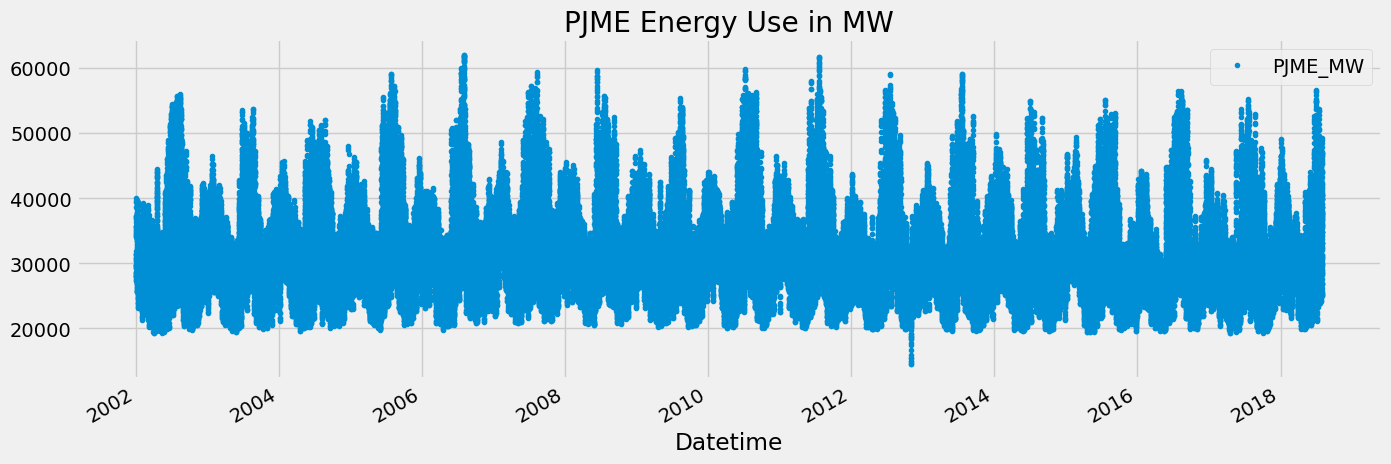

In [15]:
df.plot(style=".", figsize=(15, 5), color=color_pal[0], title='PJME Energy Use in MW')
plt.show()

#### Train/Test split

In [17]:
train = df.loc[df.index < '01-01-2015']
test = df.loc[df.index >= '01-01-2015']

In [18]:
train

,PJME_MW
Datetime,
2002-12-31 01:00:00,26498.0
2002-12-31 02:00:00,25147.0
2002-12-31 03:00:00,24574.0
2002-12-31 04:00:00,24393.0
2002-12-31 05:00:00,24860.0
...,...
2014-01-01 20:00:00,36193.0
2014-01-01 21:00:00,35601.0
2014-01-01 22:00:00,34242.0


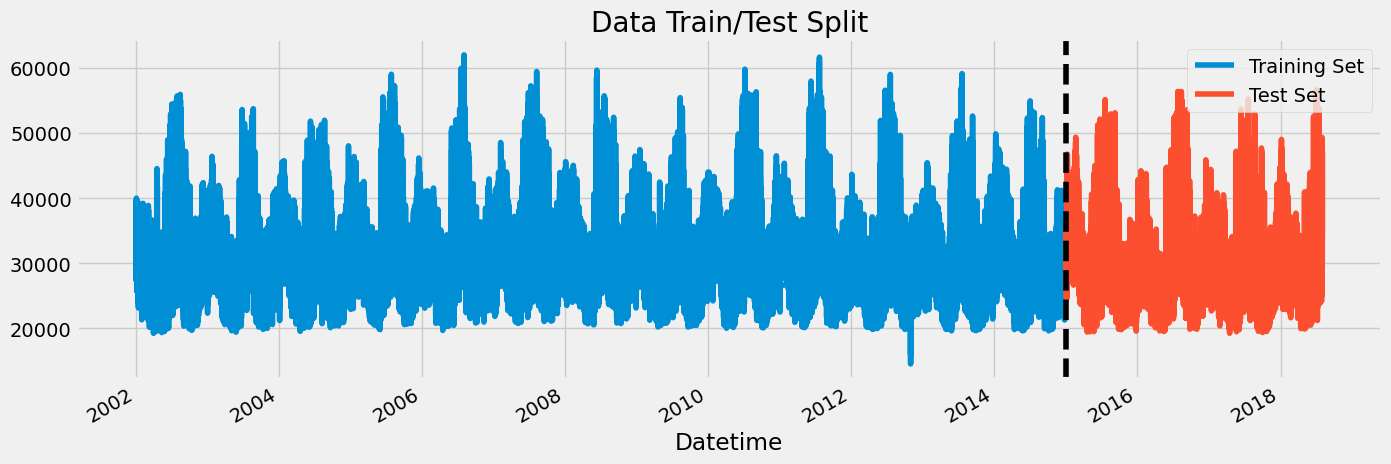

In [21]:
fig, ax = plt.subplots(figsize=(15,5))

train.plot(ax=ax, label='Training Set', title='Data Train/Test Split')
test.plot(ax=ax, label='Test Set')
ax.axvline('01-01-2015', color='black', ls='--')
ax.legend(['Training Set', 'Test Set'])
plt.show()

<Axes: title={'center': 'Week of Data'}, xlabel='Datetime'>

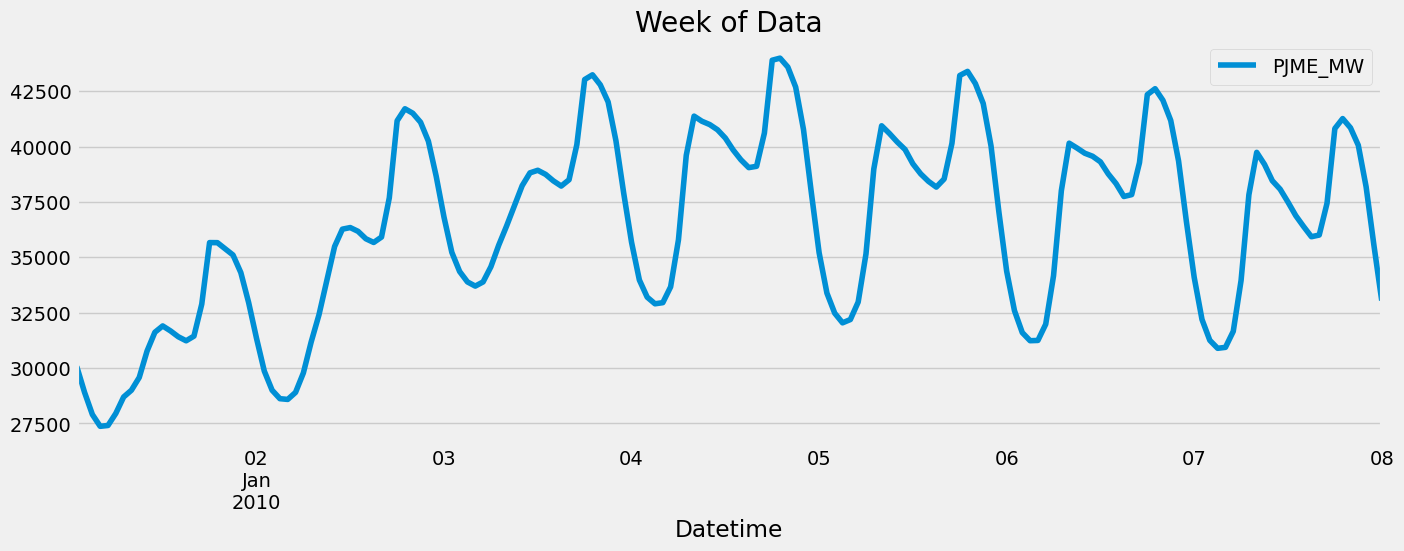

In [28]:
df.loc[(df.index > '01-01-2010') & (df.index <= '01-08-2010')].sort_values('Datetime').plot(figsize=(15,5), title='Week of Data')

#### Feature Creation

In [48]:
def create_features(df):
    """
        Create time series features based on time series index.
    """
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.day_of_week
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    return df

In [35]:
df = create_features(df)

In [36]:
df

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear
Datetime,,,,,,,
2002-12-31 01:00:00,26498.0,1,1,4,12,2002,365
2002-12-31 02:00:00,25147.0,2,1,4,12,2002,365
2002-12-31 03:00:00,24574.0,3,1,4,12,2002,365
2002-12-31 04:00:00,24393.0,4,1,4,12,2002,365
2002-12-31 05:00:00,24860.0,5,1,4,12,2002,365
...,...,...,...,...,...,...,...
2018-01-01 20:00:00,44284.0,20,0,1,1,2018,1
2018-01-01 21:00:00,43751.0,21,0,1,1,2018,1
2018-01-01 22:00:00,42402.0,22,0,1,1,2018,1


#### Visualize our features/target relationship

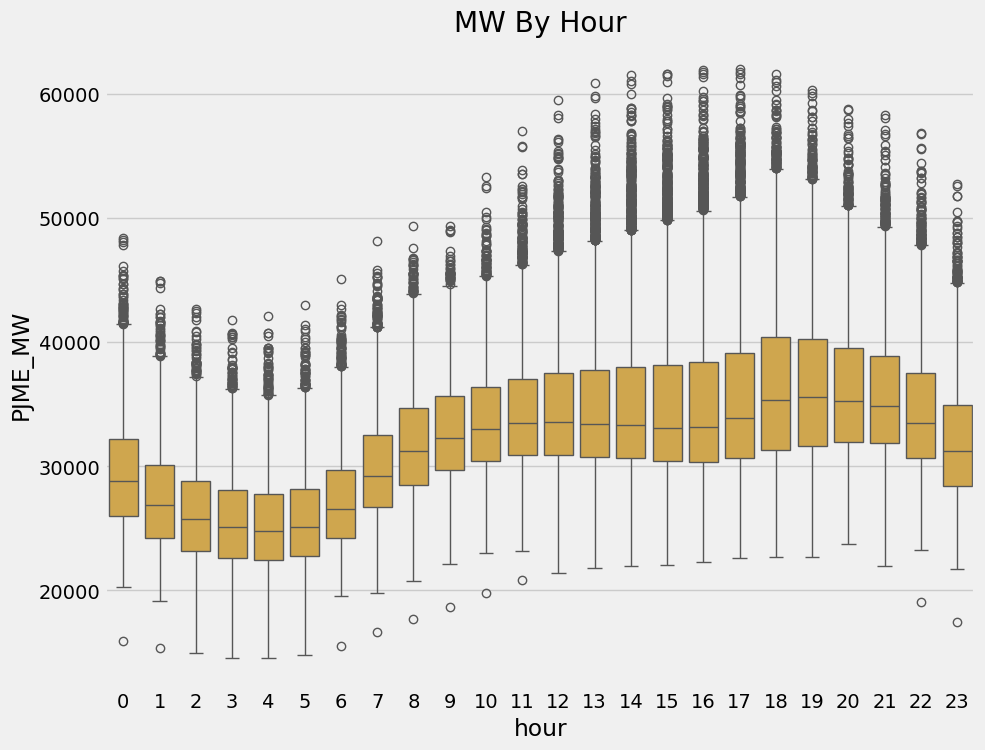

In [42]:
fig, ax = plt.subplots(figsize=(10,8))
sns.boxplot(data=df, x='hour', y='PJME_MW', color=color_pal[2])
ax.set_title('MW By Hour')
plt.show()

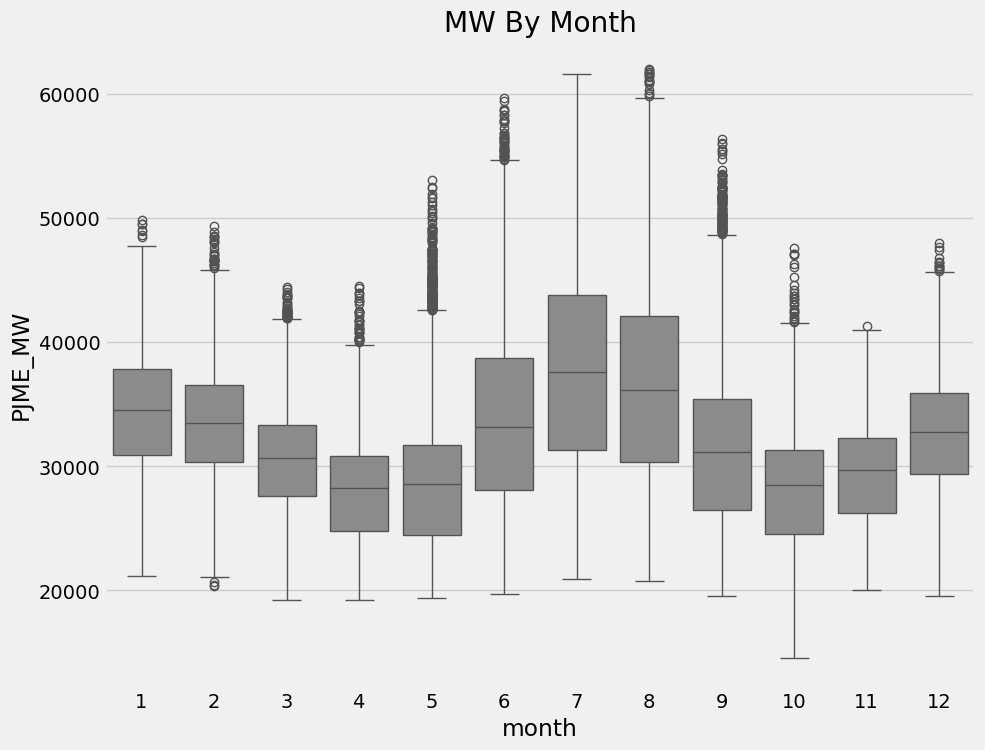

In [45]:
fig, ax = plt.subplots(figsize=(10,8))
sns.boxplot(data=df, x='month', y='PJME_MW', color=color_pal[4])
ax.set_title('MW By Month')
plt.show()

In [49]:
train = create_features(train)
test = create_features(test)

In [51]:
train

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear
Datetime,,,,,,,
2002-12-31 01:00:00,26498.0,1,1,4,12,2002,365
2002-12-31 02:00:00,25147.0,2,1,4,12,2002,365
2002-12-31 03:00:00,24574.0,3,1,4,12,2002,365
2002-12-31 04:00:00,24393.0,4,1,4,12,2002,365
2002-12-31 05:00:00,24860.0,5,1,4,12,2002,365
...,...,...,...,...,...,...,...
2014-01-01 20:00:00,36193.0,20,2,1,1,2014,1
2014-01-01 21:00:00,35601.0,21,2,1,1,2014,1
2014-01-01 22:00:00,34242.0,22,2,1,1,2014,1


In [50]:
df.columns

Index(['PJME_MW', 'hour', 'dayofweek', 'quarter', 'month', 'year',
       'dayofyear'],
      dtype='object')

In [52]:
FEATURES = ['hour', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear']
TARGET = 'PJME_MW'

In [53]:
X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

#### Create our model

In [57]:
reg = xgb.XGBRegressor(n_estimators=1000, early_stopping_rounds=50, learning_rate=0.001)
reg.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)],
       verbose=100)

[0]	validation_0-rmse:6447.78573	validation_1-rmse:6517.54145
[100]	validation_0-rmse:6026.49339	validation_1-rmse:6131.08053
[200]	validation_0-rmse:5654.75124	validation_1-rmse:5796.65490
[300]	validation_0-rmse:5326.88030	validation_1-rmse:5505.59274
[400]	validation_0-rmse:5039.56899	validation_1-rmse:5253.21086
[500]	validation_0-rmse:4788.58887	validation_1-rmse:5034.74880
[600]	validation_0-rmse:4565.97498	validation_1-rmse:4847.76655
[700]	validation_0-rmse:4372.19812	validation_1-rmse:4687.11295
[800]	validation_0-rmse:4202.53312	validation_1-rmse:4547.57144
[900]	validation_0-rmse:4055.65261	validation_1-rmse:4427.00726
[999]	validation_0-rmse:3929.32983	validation_1-rmse:4325.35302


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,50
,enable_categorical,False
,eval_metric,None


#### Feature Importance

In [58]:
reg.feature_importances_

array([0.35825273, 0.163916  , 0.0120348 , 0.3130506 , 0.01360207,
       0.1391438 ], dtype=float32)

In [60]:
fi = pd.DataFrame(data=reg.feature_importances_, index=reg.feature_names_in_, columns=['importance'])
fi

,importance
hour,0.358253
dayofweek,0.163916
quarter,0.012035
month,0.313051
year,0.013602
dayofyear,0.139144


<Axes: title={'center': 'Feature Importance'}>

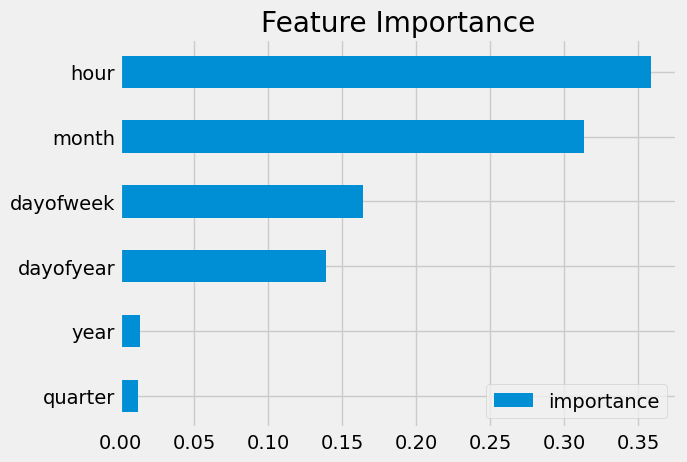

In [65]:
fi.sort_values('importance').plot(kind='barh', title='Feature Importance')

#### Forecast on test set

In [67]:
test['predictions'] = reg.predict(X_test)

In [70]:
test

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,predictions
Datetime,,,,,,,,
2015-01-01 00:00:00,32802.0,0,3,1,1,2015,1,32089.679688
2015-12-31 01:00:00,24305.0,1,3,4,12,2015,365,29669.609375
2015-12-31 02:00:00,23156.0,2,3,4,12,2015,365,28957.384766
2015-12-31 03:00:00,22514.0,3,3,4,12,2015,365,28957.384766
2015-12-31 04:00:00,22330.0,4,3,4,12,2015,365,28957.384766
...,...,...,...,...,...,...,...,...
2018-01-01 20:00:00,44284.0,20,0,1,1,2018,1,35219.347656
2018-01-01 21:00:00,43751.0,21,0,1,1,2018,1,35219.347656
2018-01-01 22:00:00,42402.0,22,0,1,1,2018,1,35138.976562


In [68]:
df

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear
Datetime,,,,,,,
2002-12-31 01:00:00,26498.0,1,1,4,12,2002,365
2002-12-31 02:00:00,25147.0,2,1,4,12,2002,365
2002-12-31 03:00:00,24574.0,3,1,4,12,2002,365
2002-12-31 04:00:00,24393.0,4,1,4,12,2002,365
2002-12-31 05:00:00,24860.0,5,1,4,12,2002,365
...,...,...,...,...,...,...,...
2018-01-01 20:00:00,44284.0,20,0,1,1,2018,1
2018-01-01 21:00:00,43751.0,21,0,1,1,2018,1
2018-01-01 22:00:00,42402.0,22,0,1,1,2018,1


In [74]:
df = df.merge(test['predictions'], how='left', left_index=True, right_index=True)
df

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,predictions
Datetime,,,,,,,,
2002-12-31 01:00:00,26498.0,1,1,4,12,2002,365,NaN
2002-12-31 02:00:00,25147.0,2,1,4,12,2002,365,NaN
2002-12-31 03:00:00,24574.0,3,1,4,12,2002,365,NaN
2002-12-31 04:00:00,24393.0,4,1,4,12,2002,365,NaN
2002-12-31 05:00:00,24860.0,5,1,4,12,2002,365,NaN
...,...,...,...,...,...,...,...,...
2018-01-01 20:00:00,44284.0,20,0,1,1,2018,1,35219.347656
2018-01-01 21:00:00,43751.0,21,0,1,1,2018,1,35219.347656
2018-01-01 22:00:00,42402.0,22,0,1,1,2018,1,35138.976562


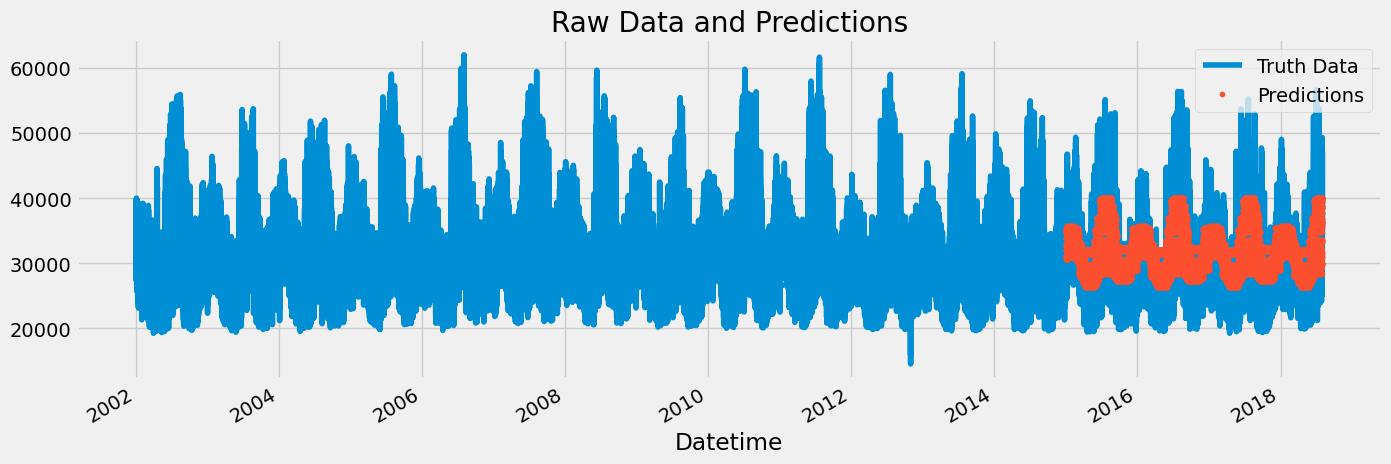

In [75]:
ax = df[['PJME_MW']].plot(figsize=(15,5))
df['predictions'].plot(ax=ax, style='.')
plt.legend(['Truth Data', 'Predictions'])
ax.set_title('Raw Data and Predictions')
plt.show()

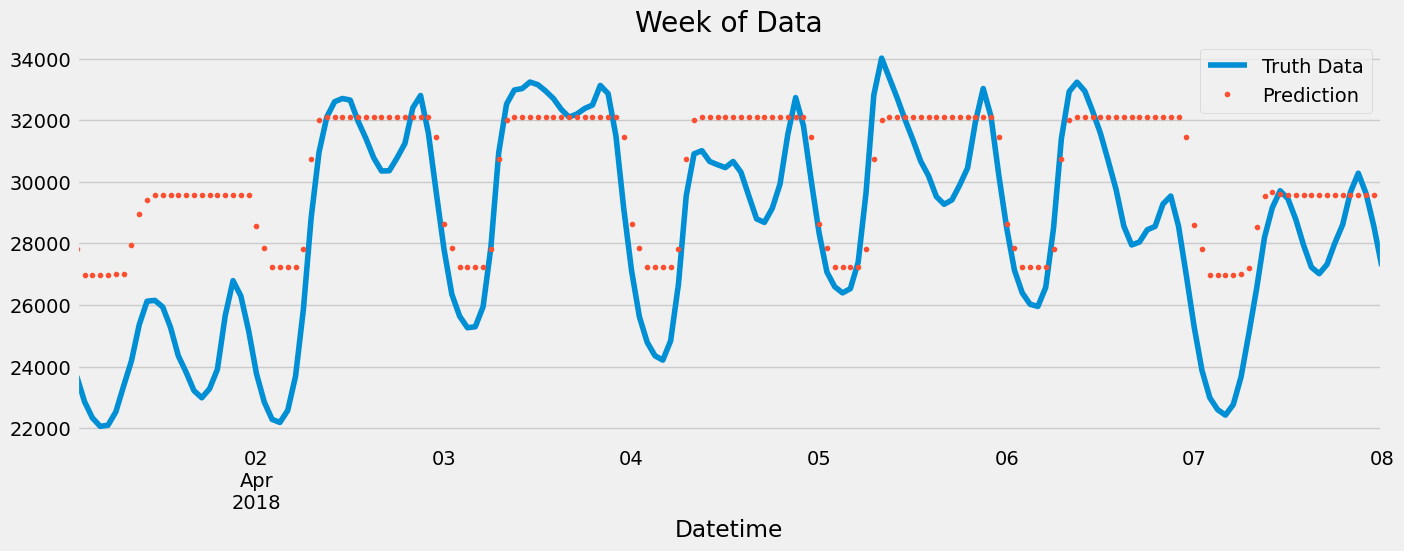

In [85]:
ax = df.loc[(df.index > '04-01-2018') & (df.index <= '04-08-2018')].sort_values('Datetime')['PJME_MW'].plot(figsize=(15,5), title='Week of Data')
df.loc[(df.index > '04-01-2018') & (df.index <= '04-08-2018')].sort_values('Datetime')['predictions'].plot(style='.')
plt.legend(['Truth Data', 'Prediction'])
plt.show()

In [87]:
score = np.sqrt(mean_squared_error(test['PJME_MW'], test['predictions']))
print(f"RMSE Score on Test Set: {score:0.2f}")

RMSE Score on Test Set: 4325.35


#### Calculate Error

- Look at the worst and the best predicted days

In [89]:
test['error'] = np.abs(test[TARGET] - test['predictions'])
test

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,predictions,error
Datetime,,,,,,,,,
2015-01-01 00:00:00,32802.0,0,3,1,1,2015,1,32089.679688,712.320312
2015-12-31 01:00:00,24305.0,1,3,4,12,2015,365,29669.609375,5364.609375
2015-12-31 02:00:00,23156.0,2,3,4,12,2015,365,28957.384766,5801.384766
2015-12-31 03:00:00,22514.0,3,3,4,12,2015,365,28957.384766,6443.384766
2015-12-31 04:00:00,22330.0,4,3,4,12,2015,365,28957.384766,6627.384766
...,...,...,...,...,...,...,...,...,...
2018-01-01 20:00:00,44284.0,20,0,1,1,2018,1,35219.347656,9064.652344
2018-01-01 21:00:00,43751.0,21,0,1,1,2018,1,35219.347656,8531.652344
2018-01-01 22:00:00,42402.0,22,0,1,1,2018,1,35138.976562,7263.023438


In [90]:
test['date'] = test.index.date

In [93]:
test.groupby('date')['error'].mean().sort_values(ascending=True).head(5)

date
2016-12-29    764.857666
2016-12-30    783.728760
2017-11-18    849.959310
2017-03-18    870.751546
2018-04-03    880.189860
Name: error, dtype: float64